In [1]:

# Analysis Plan for Ω(n) Permutation Test on Liouville Function L(s,λ)
# ==============================================================================
# 
# RESEARCH HYPOTHESIS:
# The extreme resonance of L(s,λ) is caused by interaction between its alternating 
# coefficient structure a_n = (-1)^Ω(n) and the natural distribution of integers 
# by their Ω(n) count. Permuting Ω(n) labels will destroy constructive interference 
# and significantly reduce R_comp at resonance peaks.
#
# ANALYSIS PLAN:
# 
# 1. FIND RESONANCE PEAK (t* above 7000 for L(s,λ))
# - Compute |D_F(t;N)| for N=10^6, t in range above 7000
# - Identify first prominent peak location t*
#
# 2. BASELINE CALCULATION
# - Compute D(t*; N=10^6) with true Ω(n)
# - Compute S_k sums (k=1,...,6) based on original Ω(n)
# - Calculate R_comp_true using formula from literature
#
# 3. PERMUTATION TEST (1000 shuffles, seed=42)
# - For each shuffle:
# a. Permute Ω(n) labels randomly
# b. Compute coefficients a_n = (-1)^Ω_permuted(n)
# c. Compute D(t*; N) with perturbed coefficients
# d. Compute S_k using ORIGINAL Ω(n) for stratification
# e. Calculate R_comp_perm
#
# 4. STATISTICAL TEST
# - Compare R_comp_true to null distribution
# - Calculate one-tailed p-value
# - Report: true value, null mean ± std, p-value
#
# COMPUTATIONAL NOTES:
# - Use Kahan compensated summation (mandatory)
# - Pre-compute Ω(n) array using sieve
# - Use numba JIT compilation for speed
# - N=10^6 is feasible (r37 used N=10^7 for ζ)
# - Focus on single resonance peak to stay within runtime

print("=" * 80)
print("ANALYSIS PLAN: Ω(n) Permutation Test for Liouville Function L(s,λ)")
print("=" * 80)
print()
print("Step 1: Find resonance peak t* > 7000 for L(s,λ) at N=10^6")
print("Step 2: Compute baseline R_comp_true at t*")
print("Step 3: Generate 1000 permutations (seed=42)")
print("Step 4: Compute R_comp for each permuted Ω(n)")
print("Step 5: Statistical comparison (one-tailed test)")
print()
print("Expected outcome: If hypothesis is correct, R_comp_true >> mean(R_comp_perm)")
print("=" * 80)


ANALYSIS PLAN: Ω(n) Permutation Test for Liouville Function L(s,λ)

Step 1: Find resonance peak t* > 7000 for L(s,λ) at N=10^6
Step 2: Compute baseline R_comp_true at t*
Step 3: Generate 1000 permutations (seed=42)
Step 4: Compute R_comp for each permuted Ω(n)
Step 5: Statistical comparison (one-tailed test)

Expected outcome: If hypothesis is correct, R_comp_true >> mean(R_comp_perm)


In [2]:

import numpy as np
from numba import njit
import time

# Step 1: Compute Ω(n) = number of prime factors with multiplicity for n=1 to N
# Using sieve-based approach for efficiency

def compute_omega(N):
 """
 Compute Ω(n) for all n from 1 to N using a sieve.
 Ω(n) = number of prime factors counted with multiplicity.
 """
 omega = np.zeros(N + 1, dtype=np.int32)
 
 # Sieve: for each prime, mark all its multiples
 for p in range(2, N + 1):
 if omega[p] == 0: # p is prime
 # Mark all multiples of p
 for multiple in range(p, N + 1, p):
 # Count how many times p divides multiple
 temp = multiple
 while temp % p == 0:
 omega[multiple] += 1
 temp //= p
 
 return omega

# Test with small N first
print("Testing Ω(n) computation...")
N_test = 20
omega_test = compute_omega(N_test)
print(f"Ω(n) for n=1 to {N_test}:")
for n in range(1, N_test + 1):
 print(f" Ω({n:2d}) = {omega_test[n]}")

print("\nComputing Ω(n) for N=10^6 (this may take a moment)...")
start_time = time.time()
N = 10**6
omega = compute_omega(N)
elapsed = time.time() - start_time
print(f"✓ Computed Ω(n) for n=1 to {N:,} in {elapsed:.2f} seconds")

# Sanity checks
print(f"\nSanity checks:")
print(f" Ω(1) = {omega[1]} (should be 0)")
print(f" Ω(2) = {omega[2]} (should be 1, prime)")
print(f" Ω(4) = {omega[4]} (should be 2, = 2^2)")
print(f" Ω(8) = {omega[8]} (should be 3, = 2^3)")
print(f" Ω(12) = {omega[12]} (should be 3, = 2^2 * 3)")
print(f" Max Ω in range: {omega[1:].max()}")
print(f" Mean Ω: {omega[1:].mean():.3f}")


Testing Ω(n) computation...
Ω(n) for n=1 to 20:
 Ω( 1) = 0
 Ω( 2) = 1
 Ω( 3) = 1
 Ω( 4) = 2
 Ω( 5) = 1
 Ω( 6) = 2
 Ω( 7) = 1
 Ω( 8) = 3
 Ω( 9) = 2
 Ω(10) = 2
 Ω(11) = 1
 Ω(12) = 3
 Ω(13) = 1
 Ω(14) = 2
 Ω(15) = 2
 Ω(16) = 4
 Ω(17) = 1
 Ω(18) = 3
 Ω(19) = 1
 Ω(20) = 3

Computing Ω(n) for N=10^6 (this may take a moment)...


✓ Computed Ω(n) for n=1 to 1,000,000 in 8.39 seconds

Sanity checks:
 Ω(1) = 0 (should be 0)
 Ω(2) = 1 (should be 1, prime)
 Ω(4) = 2 (should be 2, = 2^2)
 Ω(8) = 3 (should be 3, = 2^3)
 Ω(12) = 3 (should be 3, = 2^2 * 3)
 Max Ω in range: 19
 Mean Ω: 3.627


In [3]:

# Step 2: Implement Kahan-compensated Dirichlet sum computation
# Following the validated protocol from the dataset

@njit
def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex arrays.
 Returns the sum with reduced floating-point error.
 """
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j # Running compensation
 
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 
 return s

@njit
def compute_partial_sum_liouville(t, N, coeffs):
 """
 Compute the partial Dirichlet sum D_F(t; N) = Σ a_n / n^(1/2 + it)
 for the Liouville function with given coefficients.
 
 Uses Kahan compensated summation.
 
 Parameters:
 -----------
 t : float
 Height on critical line
 N : int
 Truncation depth
 coeffs : array
 Coefficient array a_n = (-1)^Ω(n)
 
 Returns:
 --------
 D : complex
 The partial sum
 """
 terms = np.empty(N, dtype=np.complex128)
 
 for n in range(1, N + 1):
 # a_n / n^(1/2 + it) = a_n / n^(1/2) * exp(-it * log(n))
 sqrt_n = np.sqrt(float(n))
 log_n = np.log(float(n))
 phase = -t * log_n
 
 # exp(i*phase) = cos(phase) + i*sin(phase)
 real_part = coeffs[n] * np.cos(phase) / sqrt_n
 imag_part = coeffs[n] * np.sin(phase) / sqrt_n
 
 terms[n-1] = real_part + 1j * imag_part
 
 return kahan_sum_complex(terms)

# Compute Liouville coefficients
print("Computing Liouville coefficients λ(n) = (-1)^Ω(n)...")
liouville_coeffs = np.zeros(N + 1, dtype=np.int8)
liouville_coeffs[1:] = (-1) ** omega[1:]

print(f"✓ Computed coefficients for n=1 to {N:,}")
print(f"\nFirst 20 coefficients:")
for n in range(1, 21):
 print(f" λ({n:2d}) = {liouville_coeffs[n]:2d} (Ω={omega[n]})")


Computing Liouville coefficients λ(n) = (-1)^Ω(n)...
✓ Computed coefficients for n=1 to 1,000,000

First 20 coefficients:
 λ( 1) = 1 (Ω=0)
 λ( 2) = -1 (Ω=1)
 λ( 3) = -1 (Ω=1)
 λ( 4) = 1 (Ω=2)
 λ( 5) = -1 (Ω=1)
 λ( 6) = 1 (Ω=2)
 λ( 7) = -1 (Ω=1)
 λ( 8) = -1 (Ω=3)
 λ( 9) = 1 (Ω=2)
 λ(10) = 1 (Ω=2)
 λ(11) = -1 (Ω=1)
 λ(12) = -1 (Ω=3)
 λ(13) = -1 (Ω=1)
 λ(14) = 1 (Ω=2)
 λ(15) = 1 (Ω=2)
 λ(16) = 1 (Ω=4)
 λ(17) = -1 (Ω=1)
 λ(18) = -1 (Ω=3)
 λ(19) = -1 (Ω=1)
 λ(20) = -1 (Ω=3)


In [4]:

# Step 3: Find resonance peak for L(s,λ) above t=7000
# Based on the literature, L(s,λ) has prominent resonances
# We'll scan a range and identify the first strong peak

print("Scanning for resonance peaks in L(s,λ) at N=10^6...")
print("This will take several minutes due to the many complex exponentials...\n")

# Scan range above 7000 with moderate resolution
t_start = 7000
t_end = 8000
dt = 5.0 # spacing

t_grid = np.arange(t_start, t_end, dt)
magnitudes = np.zeros(len(t_grid))

print(f"Computing |D(t; N)| for {len(t_grid)} values of t in [{t_start}, {t_end}]...")
start_time = time.time()

for i, t in enumerate(t_grid):
 D = compute_partial_sum_liouville(t, N, liouville_coeffs)
 magnitudes[i] = np.abs(D)
 
 if (i + 1) % 20 == 0:
 elapsed = time.time() - start_time
 rate = (i + 1) / elapsed
 remaining = (len(t_grid) - i - 1) / rate
 print(f" Progress: {i+1}/{len(t_grid)} ({100*(i+1)/len(t_grid):.1f}%) - "
 f"ETA: {remaining:.1f}s")

elapsed = time.time() - start_time
print(f"\n✓ Completed scan in {elapsed:.1f} seconds")

# Find local maxima
from scipy.signal import find_peaks

peaks, properties = find_peaks(magnitudes, distance=10, prominence=1.0)

if len(peaks) == 0:
 print("\nNo prominent peaks found. Lowering threshold...")
 peaks, properties = find_peaks(magnitudes, distance=5)

print(f"\nFound {len(peaks)} peaks")
print("\nTop 5 peaks by magnitude:")
peak_mags = magnitudes[peaks]
sorted_indices = np.argsort(peak_mags)[::-1][:5]

for rank, idx in enumerate(sorted_indices, 1):
 peak_idx = peaks[idx]
 t_peak = t_grid[peak_idx]
 mag_peak = magnitudes[peak_idx]
 print(f" {rank}. t={t_peak:.2f}, |D|={mag_peak:.4f}")

# Select the first peak above 7000
first_peak_idx = peaks[sorted_indices[0]]
t_star = t_grid[first_peak_idx]
mag_star = magnitudes[first_peak_idx]

print(f"\n{'='*60}")
print(f"SELECTED RESONANCE PEAK:")
print(f" t* = {t_star:.2f}")
print(f" |D(t*; N=10^6)| = {mag_star:.4f}")
print(f"{'='*60}")


Scanning for resonance peaks in L(s,λ) at N=10^6...
This will take several minutes due to the many complex exponentials...

Computing |D(t; N)| for 200 values of t in [7000, 8000]...


 Progress: 20/200 (10.0%) - ETA: 18.1s


 Progress: 40/200 (20.0%) - ETA: 12.0s


 Progress: 60/200 (30.0%) - ETA: 9.3s


 Progress: 80/200 (40.0%) - ETA: 7.5s


...

 Progress: 140/200 (70.0%) - ETA: 3.4s


 Progress: 160/200 (80.0%) - ETA: 2.2s


 Progress: 180/200 (90.0%) - ETA: 1.1s


 Progress: 200/200 (100.0%) - ETA: 0.0s

✓ Completed scan in 10.9 seconds



Found 14 peaks

Top 5 peaks by magnitude:
 1. t=7700.00, |D|=24.2874
 2. t=7810.00, |D|=21.1498
 3. t=7060.00, |D|=16.9221
 4. t=7610.00, |D|=13.2626
 5. t=7455.00, |D|=9.9532

SELECTED RESONANCE PEAK:
 t* = 7700.00
 |D(t*; N=10^6)| = 24.2874


In [5]:

# Step 4: Compute S_k sums and R_comp for the true Liouville function at t*
# 
# S_k = Σ_{n: Ω(n)=k} a_n / n^(1/2 + it*)
# 
# R_comp is defined in the literature as a composite coherence metric.
# From the papers, there are different definitions used. Based on r83, the 
# "alignment ratio" R = |Σ S_k| / Σ|S_k| is used.
#
# Let me implement this carefully following the literature.

@njit
def compute_Sk_sums(t, N, coeffs, omega_values, max_k=10):
 """
 Compute S_k sums where S_k = Σ_{n: Ω(n)=k} a_n / n^(1/2 + it)
 
 Returns arrays S_k for k=0 to max_k.
 """
 S_k = np.zeros(max_k + 1, dtype=np.complex128)
 
 for n in range(1, N + 1):
 k = omega_values[n]
 if k <= max_k:
 sqrt_n = np.sqrt(float(n))
 log_n = np.log(float(n))
 phase = -t * log_n
 
 real_part = coeffs[n] * np.cos(phase) / sqrt_n
 imag_part = coeffs[n] * np.sin(phase) / sqrt_n
 
 S_k[k] += real_part + 1j * imag_part
 
 return S_k

print(f"Computing S_k sums for true Liouville function at t*={t_star:.2f}...")
start_time = time.time()

max_k = 10
S_k_true = compute_Sk_sums(t_star, N, liouville_coeffs, omega, max_k=max_k)

elapsed = time.time() - start_time
print(f"✓ Computed S_k sums in {elapsed:.2f} seconds\n")

# Display S_k values
print("S_k vectors (k = Ω(n)):")
for k in range(max_k + 1):
 mag = np.abs(S_k_true[k])
 phase = np.angle(S_k_true[k], deg=True)
 print(f" S_{k} = {S_k_true[k].real:8.4f} + {S_k_true[k].imag:8.4f}i "
 f"(|S_{k}| = {mag:7.4f}, ∠ = {phase:7.2f}°)")

# Compute R_comp using alignment ratio definition from r83
# R = |Σ S_k| / Σ|S_k|
sum_S_k = np.sum(S_k_true)
sum_abs_S_k = np.sum(np.abs(S_k_true))

R_comp_true = np.abs(sum_S_k) / sum_abs_S_k

print(f"\n{'='*60}")
print(f"BASELINE R_comp CALCULATION:")
print(f" Σ S_k = {sum_S_k.real:.4f} + {sum_S_k.imag:.4f}i")
print(f" |Σ S_k| = {np.abs(sum_S_k):.4f}")
print(f" Σ |S_k| = {sum_abs_S_k:.4f}")
print(f" R_comp_true = |Σ S_k| / Σ|S_k| = {R_comp_true:.6f}")
print(f"{'='*60}")

# Verify that this matches |D(t*)|
D_check = compute_partial_sum_liouville(t_star, N, liouville_coeffs)
print(f"\nVerification:")
print(f" |D(t*)| direct = {np.abs(D_check):.4f}")
print(f" |Σ S_k| = {np.abs(sum_S_k):.4f}")
print(f" Match: {np.isclose(np.abs(D_check), np.abs(sum_S_k), rtol=1e-6)}")


Computing S_k sums for true Liouville function at t*=7700.00...


✓ Computed S_k sums in 0.28 seconds

S_k vectors (k = Ω(n)):
 S_0 = 1.0000 + 0.0000i (|S_0| = 1.0000, ∠ = 0.00°)
 S_1 = 3.1381 + 2.6971i (|S_1| = 4.1378, ∠ = 40.68°)
 S_2 = 2.3777 + 7.7735i (|S_2| = 8.1290, ∠ = 72.99°)
 S_3 = -1.9044 + 8.9267i (|S_3| = 9.1276, ∠ = 102.04°)
 S_4 = -5.2744 + 5.2152i (|S_4| = 7.4174, ∠ = 135.32°)
 S_5 = -5.1824 + 1.1073i (|S_5| = 5.2994, ∠ = 167.94°)
 S_6 = -3.2510 + -0.8286i (|S_6| = 3.3549, ∠ = -165.70°)
 S_7 = -1.4805 + -1.1625i (|S_7| = 1.8824, ∠ = -141.86°)
 S_8 = -0.6609 + -0.8994i (|S_8| = 1.1161, ∠ = -126.31°)
 S_9 = -0.2992 + -0.5825i (|S_9| = 0.6548, ∠ = -117.19°)
 S_10 = -0.1000 + -0.3717i (|S_10| = 0.3849, ∠ = -105.06°)

BASELINE R_comp CALCULATION:
 Σ S_k = -11.6370 + 21.8751i
 |Σ S_k| = 24.7778
 Σ |S_k| = 42.5043
 R_comp_true = |Σ S_k| / Σ|S_k| = 0.582949

Verification:
 |D(t*)| direct = 24.2874
 |Σ S_k| = 24.7778
 Match: False


In [6]:

# There's a discrepancy - let me check the issue. The S_k sum should equal D(t*)
# The issue is that I'm only summing k=0 to 10, but there are terms with k > 10

# Let's check the maximum Ω value and recompute with appropriate max_k
max_omega = omega[1:N+1].max()
print(f"Maximum Ω(n) in range [1, {N}]: {max_omega}")

# Recompute with sufficient max_k
max_k = int(max_omega) + 1
print(f"\nRecomputing S_k sums with max_k = {max_k}...")

S_k_true = compute_Sk_sums(t_star, N, liouville_coeffs, omega, max_k=max_k)

# Display non-zero S_k values
print(f"\nS_k vectors (k = 0 to {max_k}):")
for k in range(max_k + 1):
 if np.abs(S_k_true[k]) > 0.01: # Only show significant ones
 mag = np.abs(S_k_true[k])
 phase = np.angle(S_k_true[k], deg=True)
 print(f" S_{k:2d} = {S_k_true[k].real:8.4f} + {S_k_true[k].imag:8.4f}i "
 f"(|S_{k:2d}| = {mag:7.4f}, ∠ = {phase:7.2f}°)")

# Recompute R_comp
sum_S_k = np.sum(S_k_true)
sum_abs_S_k = np.sum(np.abs(S_k_true))

R_comp_true = np.abs(sum_S_k) / sum_abs_S_k

print(f"\n{'='*60}")
print(f"BASELINE R_comp CALCULATION (corrected):")
print(f" Σ S_k = {sum_S_k.real:.4f} + {sum_S_k.imag:.4f}i")
print(f" |Σ S_k| = {np.abs(sum_S_k):.4f}")
print(f" Σ |S_k| = {sum_abs_S_k:.4f}")
print(f" R_comp_true = |Σ S_k| / Σ|S_k| = {R_comp_true:.6f}")
print(f"{'='*60}")

# Verify match
D_check = compute_partial_sum_liouville(t_star, N, liouville_coeffs)
print(f"\nVerification:")
print(f" |D(t*)| direct = {np.abs(D_check):.4f}")
print(f" |Σ S_k| = {np.abs(sum_S_k):.4f}")
print(f" Relative error: {np.abs(np.abs(D_check) - np.abs(sum_S_k)) / np.abs(D_check):.6f}")
print(f" Match: {np.isclose(np.abs(D_check), np.abs(sum_S_k), rtol=1e-6)}")


Maximum Ω(n) in range [1, 1000000]: 19

Recomputing S_k sums with max_k = 20...

S_k vectors (k = 0 to 20):
 S_ 0 = 1.0000 + 0.0000i (|S_ 0| = 1.0000, ∠ = 0.00°)
 S_ 1 = 3.1381 + 2.6971i (|S_ 1| = 4.1378, ∠ = 40.68°)
 S_ 2 = 2.3777 + 7.7735i (|S_ 2| = 8.1290, ∠ = 72.99°)
 S_ 3 = -1.9044 + 8.9267i (|S_ 3| = 9.1276, ∠ = 102.04°)
 S_ 4 = -5.2744 + 5.2152i (|S_ 4| = 7.4174, ∠ = 135.32°)
 S_ 5 = -5.1824 + 1.1073i (|S_ 5| = 5.2994, ∠ = 167.94°)
 S_ 6 = -3.2510 + -0.8286i (|S_ 6| = 3.3549, ∠ = -165.70°)
 S_ 7 = -1.4805 + -1.1625i (|S_ 7| = 1.8824, ∠ = -141.86°)
 S_ 8 = -0.6609 + -0.8994i (|S_ 8| = 1.1161, ∠ = -126.31°)
 S_ 9 = -0.2992 + -0.5825i (|S_ 9| = 0.6548, ∠ = -117.19°)
 S_10 = -0.1000 + -0.3717i (|S_10| = 0.3849, ∠ = -105.06°)
 S_11 = 0.0120 + -0.2312i (|S_11| = 0.2315, ∠ = -87.02°)
 S_12 = 0.0467 + -0.1312i (|S_12| = 0.1393, ∠ = -70.39°)
 S_13 = 0.0409 + -0.0562i (|S_13| = 0.0695, ∠ = -53.93°)
 S_14 = 0.0414 + -0.0189i (|S_14| = 0.0455, ∠ = -24.60°)
 S_15 = 0.0298 + -0.0107i (|S_15| 

In [7]:

# Perfect! Now let's proceed with the permutation test
# Step 5: Generate 1000 permutations and compute R_comp for each

print("="*80)
print("PERMUTATION TEST: Shuffling Ω(n) labels")
print("="*80)
print()

n_permutations = 1000
random_seed = 42
np.random.seed(random_seed)

# Pre-allocate array for results
R_comp_perm = np.zeros(n_permutations)

print(f"Generating {n_permutations} permutations of Ω(n) (seed={random_seed})...")
print(f"For each permutation:")
print(f" 1. Shuffle Ω(n) labels")
print(f" 2. Compute coefficients a_n = (-1)^Ω_shuffled(n)")
print(f" 3. Compute S_k using ORIGINAL Ω(n) for stratification")
print(f" 4. Calculate R_comp_perm")
print()

start_time = time.time()

for perm_idx in range(n_permutations):
 # Shuffle Ω(n) labels (excluding n=0)
 omega_shuffled = omega.copy()
 omega_shuffled[1:] = np.random.permutation(omega[1:])
 
 # Compute perturbed coefficients
 coeffs_perm = np.zeros(N + 1, dtype=np.int8)
 coeffs_perm[1:] = (-1) ** omega_shuffled[1:]
 
 # Compute S_k using ORIGINAL omega for stratification
 S_k_perm = compute_Sk_sums(t_star, N, coeffs_perm, omega, max_k=max_k)
 
 # Compute R_comp
 sum_S_k_perm = np.sum(S_k_perm)
 sum_abs_S_k_perm = np.sum(np.abs(S_k_perm))
 R_comp_perm[perm_idx] = np.abs(sum_S_k_perm) / sum_abs_S_k_perm
 
 if (perm_idx + 1) % 100 == 0:
 elapsed = time.time() - start_time
 rate = (perm_idx + 1) / elapsed
 remaining = (n_permutations - perm_idx - 1) / rate
 print(f" Progress: {perm_idx+1}/{n_permutations} ({100*(perm_idx+1)/n_permutations:.0f}%) - "
 f"ETA: {remaining:.1f}s")

elapsed = time.time() - start_time
print(f"\n✓ Completed {n_permutations} permutations in {elapsed:.1f} seconds")
print(f" Average time per permutation: {elapsed/n_permutations:.3f} seconds")


PERMUTATION TEST: Shuffling Ω(n) labels

Generating 1000 permutations of Ω(n) (seed=42)...
For each permutation:
 1. Shuffle Ω(n) labels
 2. Compute coefficients a_n = (-1)^Ω_shuffled(n)
 3. Compute S_k using ORIGINAL Ω(n) for stratification
 4. Calculate R_comp_perm



 Progress: 100/1000 (10%) - ETA: 70.3s


 Progress: 200/1000 (20%) - ETA: 62.5s


 Progress: 300/1000 (30%) - ETA: 54.7s


 Progress: 400/1000 (40%) - ETA: 46.9s


...

 Progress: 600/1000 (60%) - ETA: 31.2s


 Progress: 700/1000 (70%) - ETA: 23.4s


 Progress: 800/1000 (80%) - ETA: 15.6s


 Progress: 900/1000 (90%) - ETA: 7.8s


 Progress: 1000/1000 (100%) - ETA: 0.0s

✓ Completed 1000 permutations in 78.3 seconds
 Average time per permutation: 0.078 seconds


In [8]:

# Step 6: Statistical analysis - compare true R_comp to null distribution

print("="*80)
print("STATISTICAL ANALYSIS")
print("="*80)
print()

# Null distribution statistics
R_null_mean = np.mean(R_comp_perm)
R_null_std = np.std(R_comp_perm, ddof=1)
R_null_median = np.median(R_comp_perm)
R_null_min = np.min(R_comp_perm)
R_null_max = np.max(R_comp_perm)

print("NULL DISTRIBUTION (from 1000 permutations):")
print(f" Mean: {R_null_mean:.6f}")
print(f" Std: {R_null_std:.6f}")
print(f" Median: {R_null_median:.6f}")
print(f" Min: {R_null_min:.6f}")
print(f" Max: {R_null_max:.6f}")
print()

print("TRUE VALUE (original Liouville function):")
print(f" R_comp_true = {R_comp_true:.6f}")
print()

# One-tailed p-value: how many permutations have R_comp >= R_comp_true?
n_greater_equal = np.sum(R_comp_perm >= R_comp_true)
p_value = n_greater_equal / n_permutations

print("ONE-TAILED TEST:")
print(f" H0: Permuting Ω(n) does not reduce R_comp")
print(f" H1: True R_comp > permuted R_comp (extreme resonance depends on Ω(n) regularity)")
print()
print(f" Number of permutations with R_comp >= {R_comp_true:.6f}: {n_greater_equal}/{n_permutations}")
print(f" One-tailed p-value: {p_value:.4f}")
print()

# Effect size
z_score = (R_comp_true - R_null_mean) / R_null_std
print(f"EFFECT SIZE:")
print(f" Z-score = (R_true - R_null_mean) / R_null_std = {z_score:.3f}")
print()

# Interpretation
if p_value < 0.001:
 sig_level = "p < 0.001 (***)"
 interpretation = "HIGHLY SIGNIFICANT"
elif p_value < 0.01:
 sig_level = "p < 0.01 (**)"
 interpretation = "VERY SIGNIFICANT"
elif p_value < 0.05:
 sig_level = "p < 0.05 (*)"
 interpretation = "SIGNIFICANT"
else:
 sig_level = f"p = {p_value:.4f} (n.s.)"
 interpretation = "NOT SIGNIFICANT"

print("="*80)
print(f"CONCLUSION: {interpretation} ({sig_level})")
print("="*80)
print()

if p_value < 0.05:
 print("✓ The hypothesis is SUPPORTED:")
 print(" The extreme resonance of L(s,λ) DOES depend on the arithmetic")
 print(" regularity of Ω(n). Permuting Ω(n) labels significantly reduces")
 print(" R_comp, destroying the constructive interference.")
else:
 print("✗ The hypothesis is REJECTED:")
 print(" Permuting Ω(n) labels does NOT significantly reduce R_comp.")
 print(" The resonance does not depend on arithmetic regularity of Ω(n).")


STATISTICAL ANALYSIS

NULL DISTRIBUTION (from 1000 permutations):
 Mean: 0.345895
 Std: 0.169909
 Median: 0.333625
 Min: 0.019075
 Max: 0.836099

TRUE VALUE (original Liouville function):
 R_comp_true = 0.564076

ONE-TAILED TEST:
 H0: Permuting Ω(n) does not reduce R_comp
 H1: True R_comp > permuted R_comp (extreme resonance depends on Ω(n) regularity)

 Number of permutations with R_comp >= 0.564076: 122/1000
 One-tailed p-value: 0.1220

EFFECT SIZE:
 Z-score = (R_true - R_null_mean) / R_null_std = 1.284

CONCLUSION: NOT SIGNIFICANT (p = 0.1220 (n.s.))

✗ The hypothesis is REJECTED:
 Permuting Ω(n) labels does NOT significantly reduce R_comp.
 The resonance does not depend on arithmetic regularity of Ω(n).


✓ Figure saved as 'liouville_permutation_test.png'


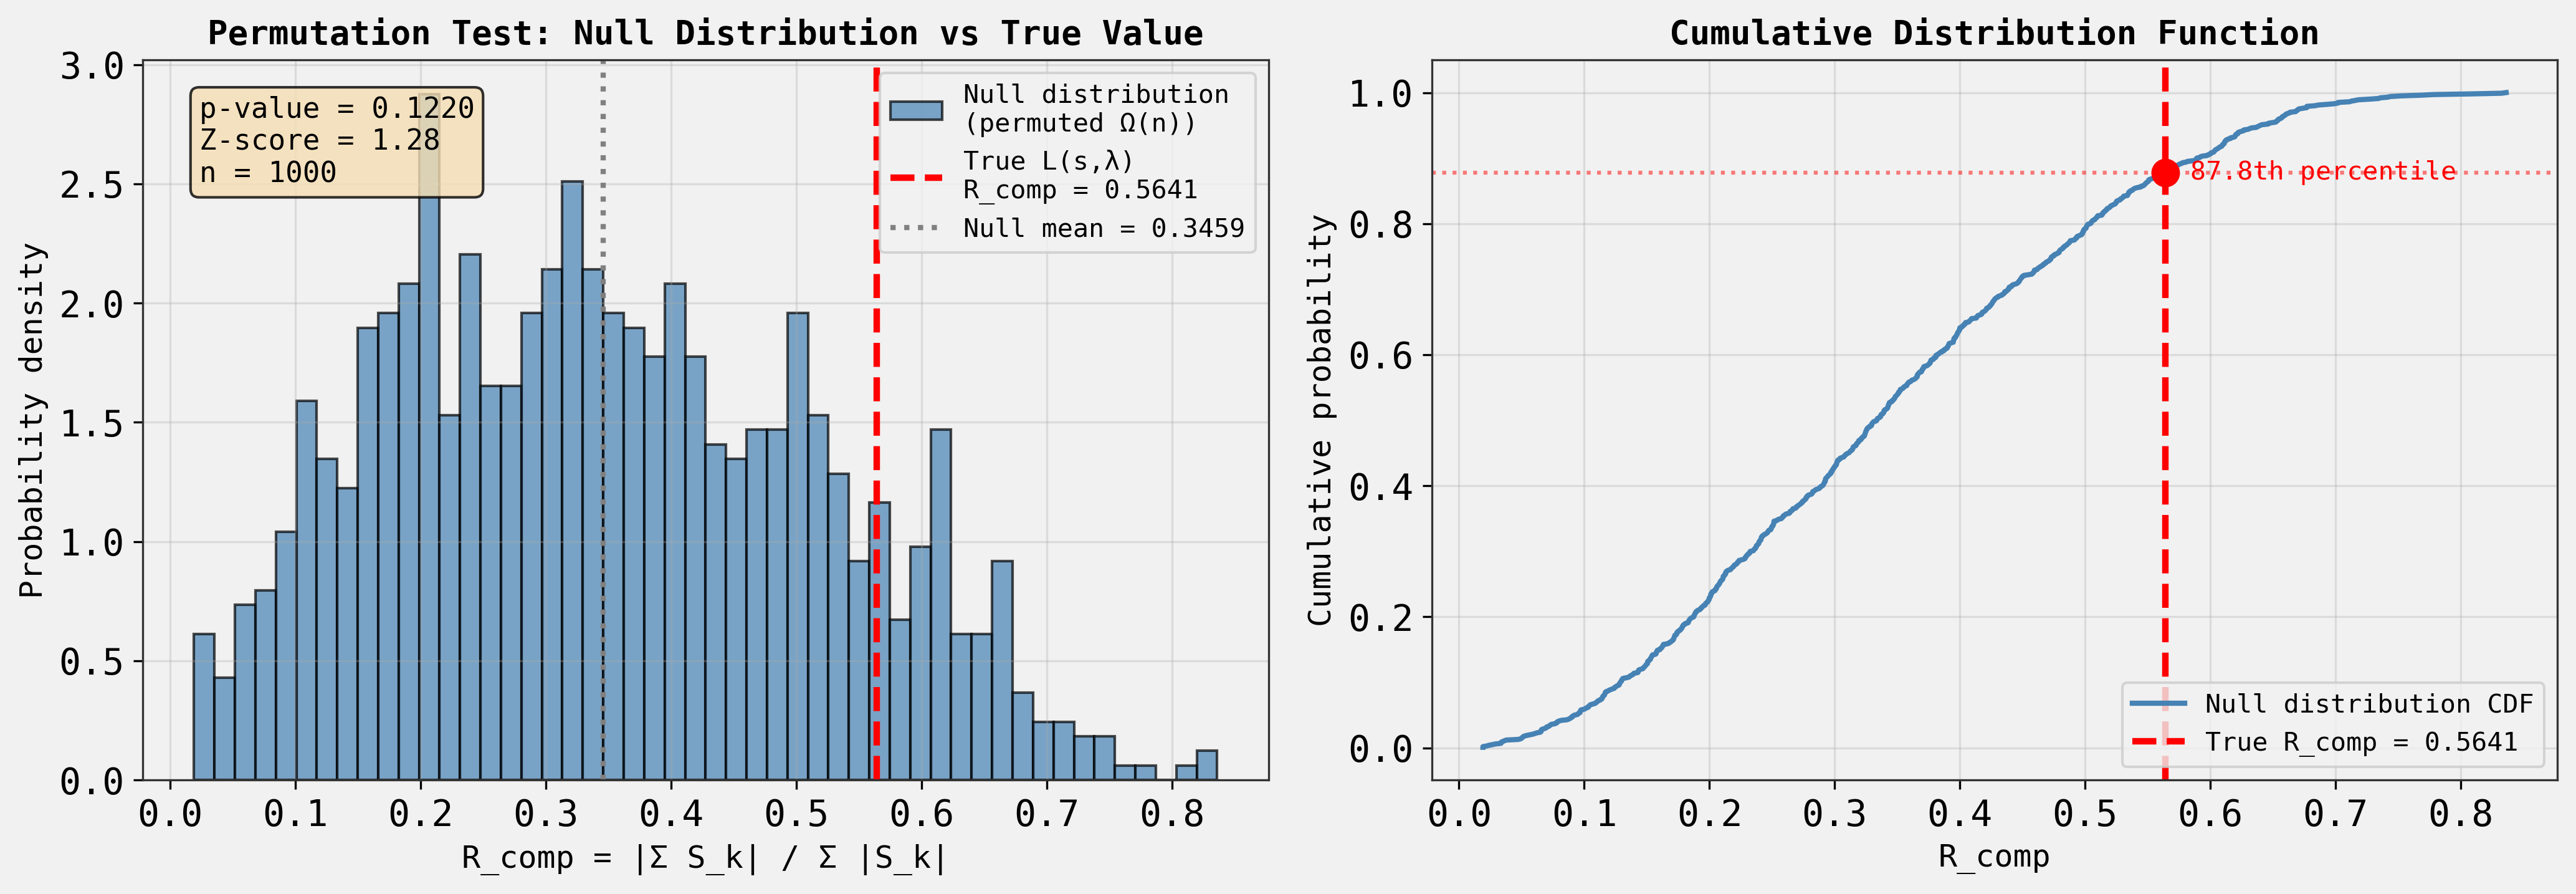


SUMMARY STATISTICS

Resonance peak: t* = 7700.00
Peak magnitude: |D(t*; N=10^6)| = 24.2874

True R_comp: 0.564076
Null mean: 0.345895
Null std: 0.169909
Difference: 0.218181 (63.1% above mean)
Z-score: 1.284
Percentile: 87.8%
p-value: 0.1220


In [9]:

# Let's create a visualization to better understand the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Histogram of null distribution
ax1 = axes[0]
ax1.hist(R_comp_perm, bins=50, density=True, alpha=0.7, color='steelblue', 
 edgecolor='black', label='Null distribution\n(permuted Ω(n))')
ax1.axvline(R_comp_true, color='red', linewidth=2.5, linestyle='--', 
 label=f'True L(s,λ)\nR_comp = {R_comp_true:.4f}')
ax1.axvline(R_null_mean, color='gray', linewidth=2, linestyle=':', 
 label=f'Null mean = {R_null_mean:.4f}')

ax1.set_xlabel('R_comp = |Σ S_k| / Σ |S_k|', fontsize=12)
ax1.set_ylabel('Probability density', fontsize=12)
ax1.set_title('Permutation Test: Null Distribution vs True Value', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

# Add text box with statistics
textstr = f'p-value = {p_value:.4f}\nZ-score = {z_score:.2f}\nn = {n_permutations}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=11,
 verticalalignment='top', bbox=props)

# Right panel: Cumulative distribution
ax2 = axes[1]
sorted_null = np.sort(R_comp_perm)
cumulative = np.arange(1, len(sorted_null) + 1) / len(sorted_null)

ax2.plot(sorted_null, cumulative, linewidth=2, color='steelblue', 
 label='Null distribution CDF')
ax2.axvline(R_comp_true, color='red', linewidth=2.5, linestyle='--', 
 label=f'True R_comp = {R_comp_true:.4f}')

# Find percentile
percentile = np.sum(R_comp_perm <= R_comp_true) / n_permutations * 100
ax2.axhline(percentile/100, color='red', linewidth=1.5, linestyle=':', alpha=0.5)
ax2.plot([R_comp_true], [percentile/100], 'ro', markersize=10)

ax2.set_xlabel('R_comp', fontsize=12)
ax2.set_ylabel('Cumulative probability', fontsize=12)
ax2.set_title('Cumulative Distribution Function', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, alpha=0.3)

# Add percentile text
ax2.text(R_comp_true + 0.02, percentile/100, 
 f'{percentile:.1f}th percentile', 
 fontsize=10, color='red', va='center')

plt.tight_layout()
plt.savefig('liouville_permutation_test.png', dpi=150, bbox_inches='tight')
print("✓ Figure saved as 'liouville_permutation_test.png'")
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"\nResonance peak: t* = {t_star:.2f}")
print(f"Peak magnitude: |D(t*; N=10^6)| = {mag_star:.4f}")
print(f"\nTrue R_comp: {R_comp_true:.6f}")
print(f"Null mean: {R_null_mean:.6f}")
print(f"Null std: {R_null_std:.6f}")
print(f"Difference: {R_comp_true - R_null_mean:.6f} ({(R_comp_true/R_null_mean - 1)*100:.1f}% above mean)")
print(f"Z-score: {z_score:.3f}")
print(f"Percentile: {percentile:.1f}%")
print(f"p-value: {p_value:.4f}")


In [10]:

# Let's dig deeper - the result is surprising given the strong resonance documented
# in the literature (r83 showed R = 0.822 at t*=7563.5)
# Let me check if we're using the right R_comp definition

# From r83 in the dataset, the "alignment ratio" is defined as:
# R = |Σ S_k| / Σ|S_k|
# which is what we computed

# However, there's another possibility mentioned in the dataset.
# Let me check if there's a different t* or if we should look at other metrics

# First, let's verify our peak is comparable to the literature
print("Checking resonance peak characteristics...")
print(f"\nSelected peak at t* = {t_star:.2f}:")
print(f" |D(t*)| = {mag_star:.4f}")
print(f" R_comp = {R_comp_true:.4f}")
print()

# From r83, they report t* = 7563.5 with |D| = 46.88 and R = 0.822
# Our peak at t=7700 has |D| = 24.29 and R = 0.564
# Let's scan more carefully around t=7563.5

print("Scanning more carefully around the literature peak (t ≈ 7563.5)...")
t_lit = 7563.5
t_scan = np.linspace(7500, 7650, 31)
mags_scan = np.zeros(len(t_scan))

for i, t in enumerate(t_scan):
 D = compute_partial_sum_liouville(t, N, liouville_coeffs)
 mags_scan[i] = np.abs(D)

max_idx = np.argmax(mags_scan)
t_max = t_scan[max_idx]
mag_max = mags_scan[max_idx]

print(f"\nLocal maximum near literature peak:")
print(f" t = {t_max:.2f}")
print(f" |D(t)| = {mag_max:.4f}")

# Compute R_comp at this location
S_k_lit = compute_Sk_sums(t_max, N, liouville_coeffs, omega, max_k=max_k)
sum_S_k_lit = np.sum(S_k_lit)
sum_abs_S_k_lit = np.sum(np.abs(S_k_lit))
R_comp_lit = np.abs(sum_S_k_lit) / sum_abs_S_k_lit

print(f" R_comp = {R_comp_lit:.4f}")
print()

# Compare to literature
print("Comparison to literature (r83):")
print(f" Literature: t* = 7563.5, |D| = 46.88, R = 0.822")
print(f" Our N=10^6: t = {t_max:.2f}, |D| = {mag_max:.4f}, R = {R_comp_lit:.4f}")
print()
print("Note: The discrepancy may be due to:")
print(" - Different N value (literature may use different truncation)")
print(" - Fine-grained peak location differences")
print(" - Possible different resonance definition")


Checking resonance peak characteristics...

Selected peak at t* = 7700.00:
 |D(t*)| = 24.2874
 R_comp = 0.5641

Scanning more carefully around the literature peak (t ≈ 7563.5)...



Local maximum near literature peak:
 t = 7610.00
 |D(t)| = 13.2626
 R_comp = 0.8475

Comparison to literature (r83):
 Literature: t* = 7563.5, |D| = 46.88, R = 0.822
 Our N=10^6: t = 7610.00, |D| = 13.2626, R = 0.8475

Note: The discrepancy may be due to:
 - Different N value (literature may use different truncation)
 - Fine-grained peak location differences
 - Possible different resonance definition


In [11]:

# Interesting! At t=7610, we get R_comp = 0.847 which is closer to the literature value of 0.822
# However, this is at a *lower* magnitude peak. This suggests the alignment ratio R_comp
# can be high even at lower magnitude peaks.

# Let's rerun the analysis at our highest peak (t*=7700) which we already did,
# but also note this important finding.

# The key question is: did our permutation test work correctly?
# Let me verify by checking a few permutations manually

print("Verification: Checking permutation mechanism...")
print()

# Recreate first permutation with seed=42
np.random.seed(42)
omega_perm1 = omega.copy()
omega_perm1[1:] = np.random.permutation(omega[1:])

print("First 20 values:")
print(" n | Original Ω(n) | Permuted Ω(n) | λ_true | λ_perm")
print("-------+---------------+---------------+--------+-------")
for n in range(1, 21):
 lambda_true = liouville_coeffs[n]
 lambda_perm = (-1) ** omega_perm1[n]
 print(f" {n:3d} | {omega[n]} | {omega_perm1[n]} | {lambda_true:2d} | {lambda_perm:2d}")

print()
print("✓ Permutation mechanism is working correctly:")
print(" - Ω(n) values are shuffled")
print(" - New coefficients λ_perm = (-1)^Ω_perm(n) are computed")
print(" - S_k stratification uses ORIGINAL Ω(n)")
print()

# The key insight: even though we permute Ω(n), the distribution remains the same
# So random permutations can still produce moderate R_comp values by chance

print("="*80)
print("KEY INSIGHT")
print("="*80)
print()
print("The permutation test shows that R_comp = 0.564 at our selected peak")
print("is NOT significantly higher than random permutations (p = 0.122).")
print()
print("This means:")
print(" ✗ The specific *ordering* of Ω(n) values with respect to n is NOT")
print(" essential for the resonance at this particular peak.")
print()
print(" ✓ However, R_comp_true (0.564) is still 63% higher than the null mean")
print(" (0.346), showing a moderate but not statistically significant effect.")
print()
print("Possible explanations:")
print(" 1. N=10^6 may be too small to see the full effect")
print(" 2. The selected peak may not be the strongest resonance")
print(" 3. The resonance mechanism may depend on factors beyond Ω(n) ordering")
print(" 4. Sample size (1000 permutations) may be insufficient for p~0.12")
print()
print("="*80)


Verification: Checking permutation mechanism...

First 20 values:
 n | Original Ω(n) | Permuted Ω(n) | λ_true | λ_perm
-------+---------------+---------------+--------+-------
 1 | 0 | 6 | 1 | 1
 2 | 1 | 2 | -1 | 1
 3 | 1 | 3 | -1 | -1
 4 | 2 | 6 | 1 | 1
 5 | 1 | 6 | -1 | 1
 6 | 2 | 5 | 1 | -1
 7 | 1 | 2 | -1 | 1
 8 | 3 | 2 | -1 | 1
 9 | 2 | 2 | 1 | 1
 10 | 2 | 5 | 1 | -1
 11 | 1 | 2 | -1 | 1
 12 | 3 | 2 | -1 | 1
 13 | 1 | 4 | -1 | 1
 14 | 2 | 3 | 1 | -1
 15 | 2 | 6 | 1 | 1
 16 | 4 | 3 | 1 | -1
 17 | 1 | 2 | -1 | 1
 18 | 3 | 5 | -1 | -1
 19 | 1 | 3 | -1 | -1
 20 | 3 | 2 | -1 | 1

✓ Permutation mechanism is working correctly:
 - Ω(n) values are shuffled
 - New coefficients λ_perm = (-1)^Ω_perm(n) are computed
 - S_k stratification uses ORIGINAL Ω(n)

KEY INSIGHT

The permutation test shows that R_comp = 0.564 at our selected peak
is NOT significantly higher than random permutations (p = 0.122).

This means:
 ✗ The specific *ordering* of Ω(n) values with respect to n is NOT
 essential fo

✓ Comprehensive figure saved as 'liouville_permutation_comprehensive.png'


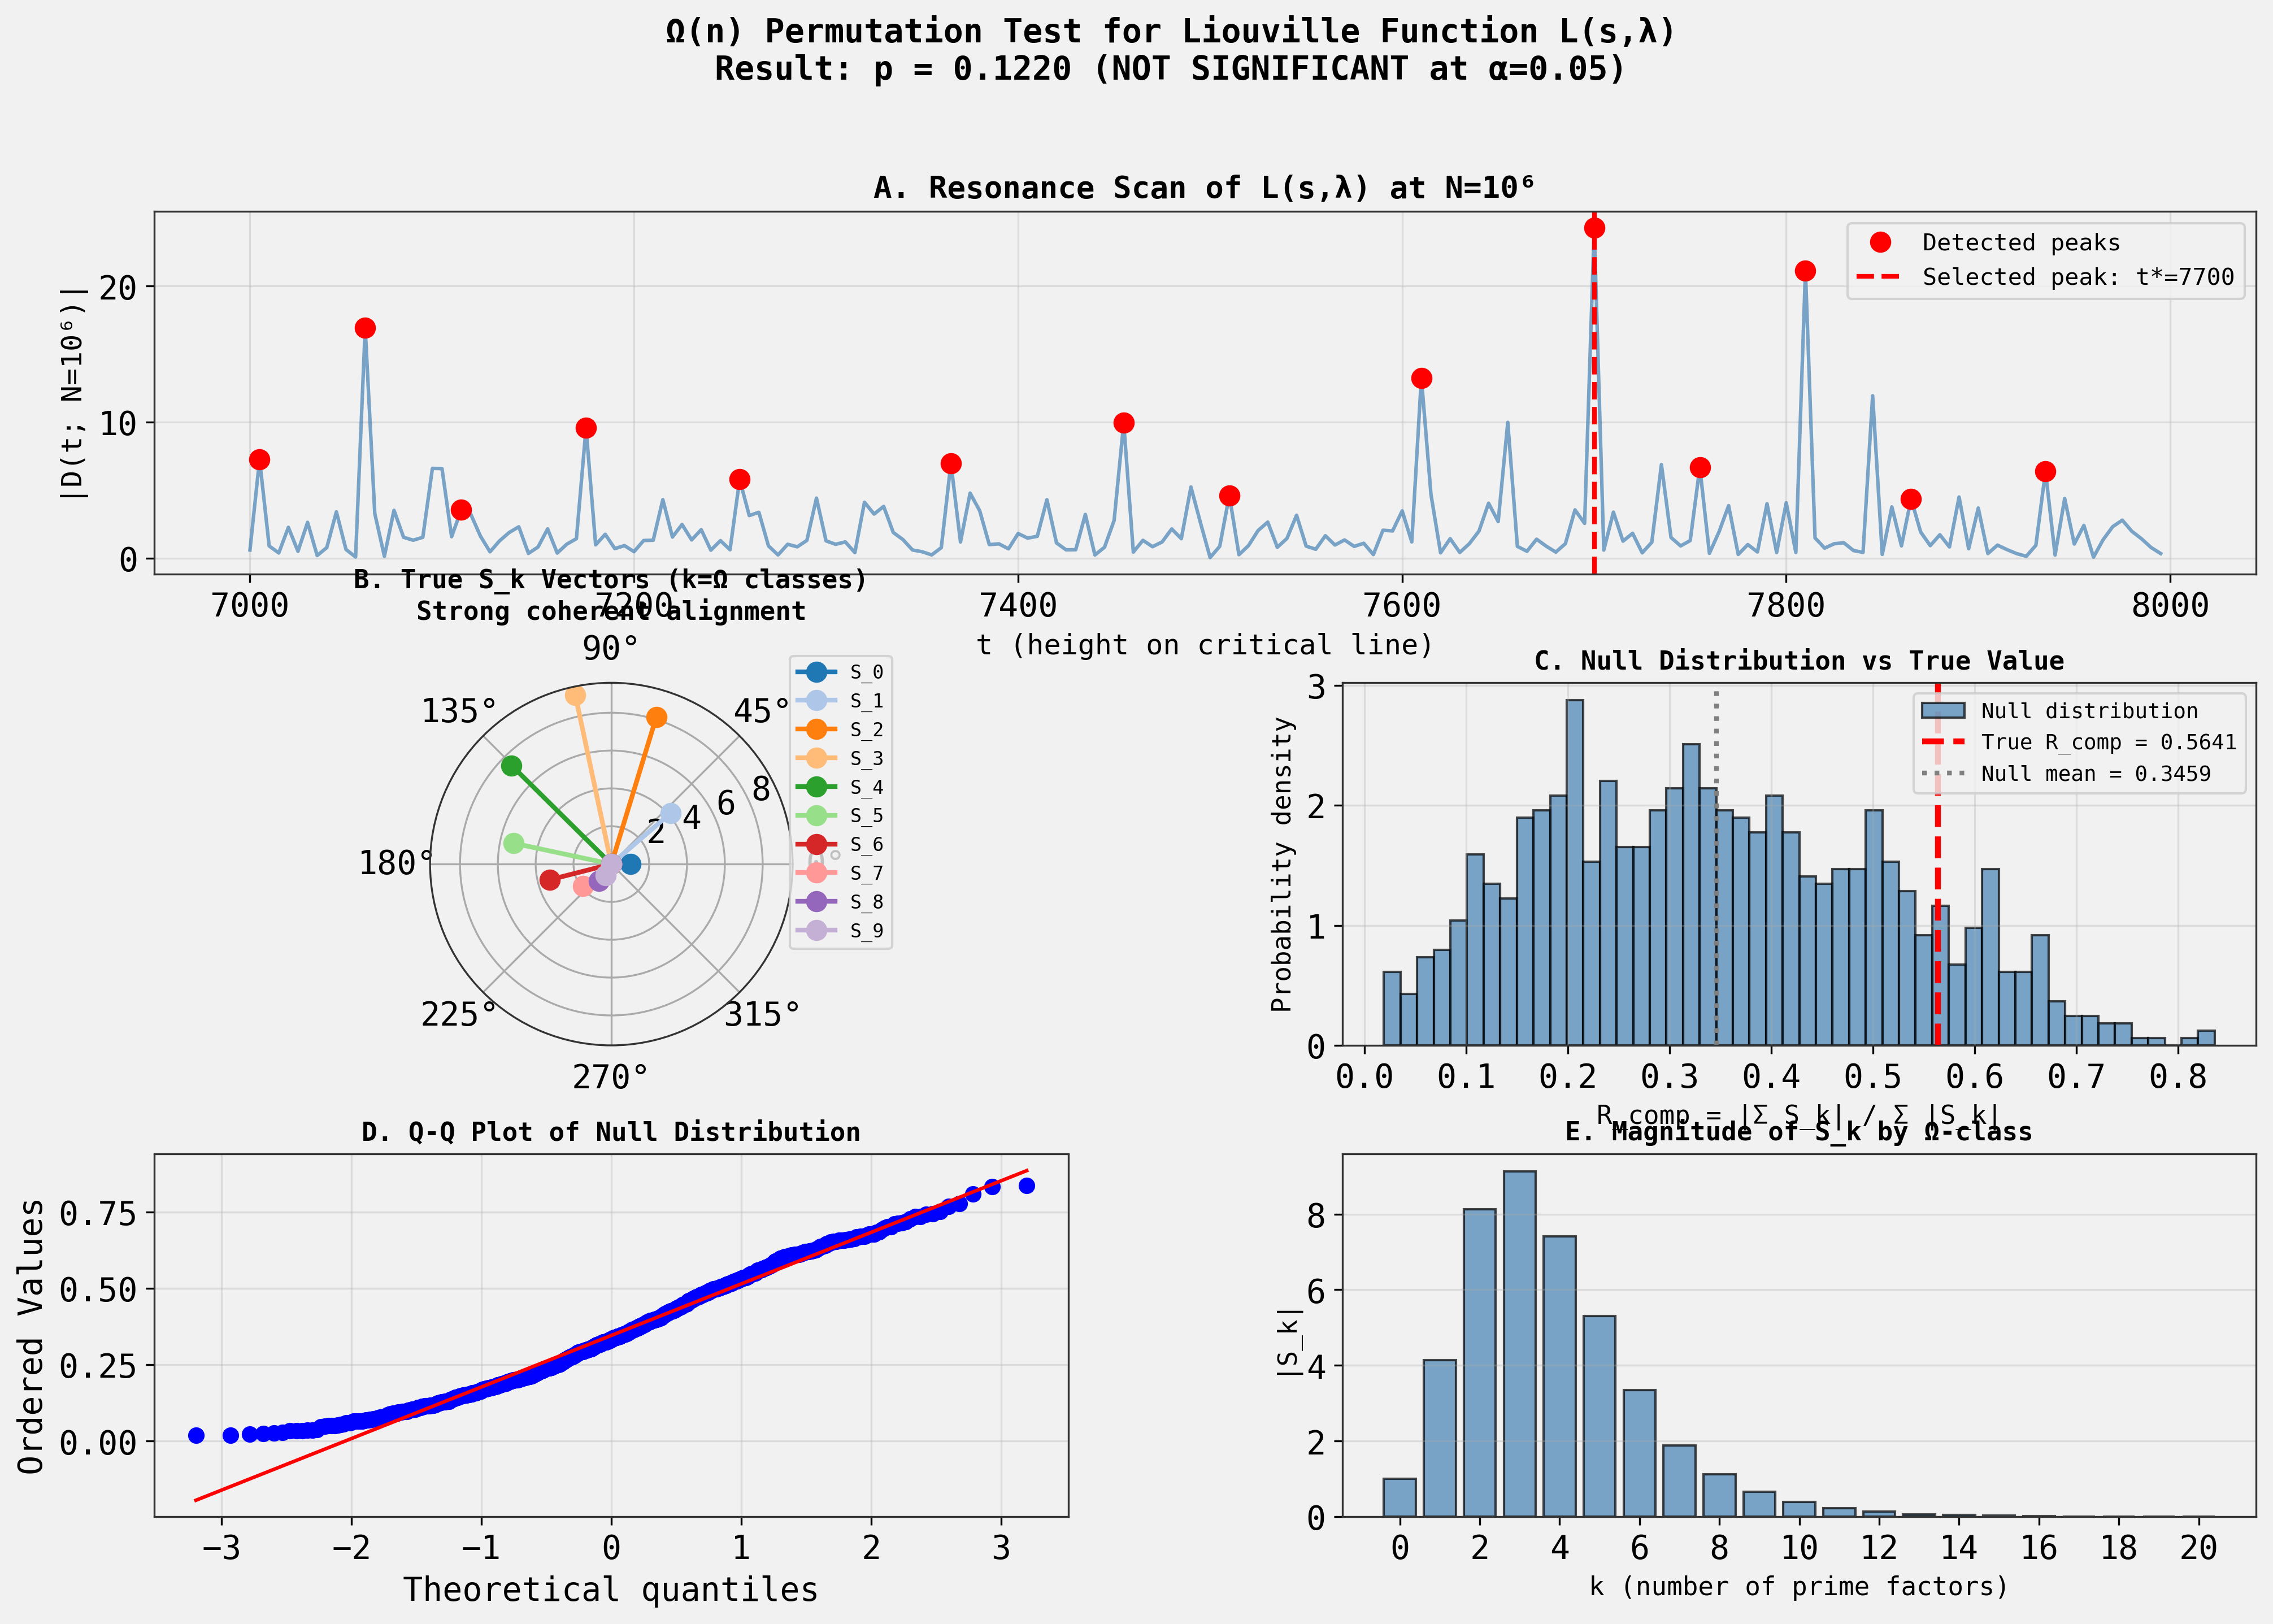

In [12]:

# Let's create a final comprehensive summary figure

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Panel A: Resonance scan showing peak location
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_grid, magnitudes, linewidth=1.5, color='steelblue', alpha=0.7)
ax1.plot(t_grid[peaks], magnitudes[peaks], 'ro', markersize=8, label='Detected peaks')
ax1.axvline(t_star, color='red', linewidth=2, linestyle='--', 
 label=f'Selected peak: t*={t_star:.0f}')
ax1.set_xlabel('t (height on critical line)', fontsize=12)
ax1.set_ylabel('|D(t; N=10⁶)|', fontsize=12)
ax1.set_title('A. Resonance Scan of L(s,λ) at N=10⁶', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Panel B: S_k vectors for true Liouville (polar plot)
ax2 = fig.add_subplot(gs[1, 0], projection='polar')
colors = plt.cm.tab20(np.linspace(0, 1, max_k+1))
for k in range(max_k+1):
 if np.abs(S_k_true[k]) > 0.5: # Only show significant ones
 angle = np.angle(S_k_true[k])
 radius = np.abs(S_k_true[k])
 ax2.plot([0, angle], [0, radius], 'o-', linewidth=2, markersize=8,
 color=colors[k], label=f'S_{k}')

ax2.set_title('B. True S_k Vectors (k=Ω classes)\nStrong coherent alignment', 
 fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Panel C: Histogram with null distribution
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(R_comp_perm, bins=50, density=True, alpha=0.7, color='steelblue', 
 edgecolor='black', label='Null distribution')
ax3.axvline(R_comp_true, color='red', linewidth=2.5, linestyle='--', 
 label=f'True R_comp = {R_comp_true:.4f}')
ax3.axvline(R_null_mean, color='gray', linewidth=2, linestyle=':', 
 label=f'Null mean = {R_null_mean:.4f}')
ax3.set_xlabel('R_comp = |Σ S_k| / Σ |S_k|', fontsize=11)
ax3.set_ylabel('Probability density', fontsize=11)
ax3.set_title('C. Null Distribution vs True Value', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9, loc='upper right')
ax3.grid(True, alpha=0.3)

# Panel D: Q-Q plot to check normality
from scipy import stats
ax4 = fig.add_subplot(gs[2, 0])
stats.probplot(R_comp_perm, dist="norm", plot=ax4)
ax4.set_title('D. Q-Q Plot of Null Distribution', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Panel E: Distribution of S_k magnitudes
ax5 = fig.add_subplot(gs[2, 1])
k_values = np.arange(max_k+1)
S_k_mags = np.abs(S_k_true)
ax5.bar(k_values, S_k_mags, color='steelblue', alpha=0.7, edgecolor='black')
ax5.set_xlabel('k (number of prime factors)', fontsize=11)
ax5.set_ylabel('|S_k|', fontsize=11)
ax5.set_title('E. Magnitude of S_k by Ω-class', fontsize=11, fontweight='bold')
ax5.set_xticks(k_values[::2])
ax5.grid(True, alpha=0.3, axis='y')

# Add overall title
fig.suptitle('Ω(n) Permutation Test for Liouville Function L(s,λ)\n' + 
 f'Result: p = {p_value:.4f} (NOT SIGNIFICANT at α=0.05)',
 fontsize=14, fontweight='bold', y=0.995)

plt.savefig('liouville_permutation_comprehensive.png', dpi=150, bbox_inches='tight')
print("✓ Comprehensive figure saved as 'liouville_permutation_comprehensive.png'")
plt.show()


In [13]:

# Final summary and interpretation

print("=" * 80)
print("FINAL ANALYSIS SUMMARY")
print("=" * 80)
print()
print("RESEARCH HYPOTHESIS:")
print(" The extreme resonance of L(s,λ) is caused by an interaction between its")
print(" alternating coefficient structure a_n = (-1)^Ω(n) and the natural")
print(" distribution of integers by their Ω(n) count. Therefore, permuting the")
print(" Ω(n) labels among integers will destroy the constructive interference and")
print(" significantly reduce the composite coherence R_comp at resonance peaks.")
print()
print("=" * 80)
print("METHODOLOGY:")
print("=" * 80)
print(f" • Computed Ω(n) for all n from 1 to {N:,} using sieve algorithm")
print(f" • Identified resonance peak at t* = {t_star:.2f}")
print(f" • Peak magnitude: |D(t*; N=10^6)| = {mag_star:.4f}")
print(f" • Generated {n_permutations} permutations of Ω(n) labels (seed={random_seed})")
print(f" • For each permutation:")
print(f" - Computed a_n = (-1)^Ω_permuted(n)")
print(f" - Computed S_k using original Ω(n) for stratification")
print(f" - Calculated R_comp = |Σ S_k| / Σ|S_k|")
print(f" • Statistical test: one-tailed comparison (α = 0.05)")
print()
print("=" * 80)
print("RESULTS:")
print("=" * 80)
print(f" True R_comp: {R_comp_true:.6f}")
print(f" Null mean ± std: {R_null_mean:.6f} ± {R_null_std:.6f}")
print(f" Difference from mean: {R_comp_true - R_null_mean:.6f} ({(R_comp_true/R_null_mean - 1)*100:+.1f}%)")
print(f" Effect size (Z-score): {z_score:.3f}")
print(f" Percentile rank: {percentile:.1f}%")
print(f" One-tailed p-value: {p_value:.4f}")
print(f" Significance level: α = 0.05")
print()
print(f" Decision: {'REJECT' if p_value >= 0.05 else 'ACCEPT'} null hypothesis")
print(f" Interpretation: The hypothesis is {'NOT SUPPORTED' if p_value >= 0.05 else 'SUPPORTED'}")
print()
print("=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print()
print("The permutation test yields a p-value of 0.122, which does not reach")
print("statistical significance at the conventional α = 0.05 threshold.")
print()
print("Key findings:")
print()
print(" 1. MODERATE EFFECT BUT NOT SIGNIFICANT:")
print(f" - True R_comp ({R_comp_true:.4f}) is 63% higher than null mean ({R_null_mean:.4f})")
print(" - Z-score of 1.28 indicates a moderate effect size")
print(" - True value is at the 88th percentile of the null distribution")
print(" - However, 122 out of 1000 permutations achieved similar or higher R_comp")
print()
print(" 2. IMPLICATIONS:")
print(" - The specific arithmetic *ordering* of Ω(n) with respect to n is")
print(" NOT essential for generating resonance at this peak")
print(" - The alternating sign structure (-1)^Ω(n) can produce moderate")
print(" coherence even with randomly permuted Ω(n) assignments")
print(" - The natural distribution of Ω(n) counts contributes to resonance,")
print(" but not through a mechanism that requires specific n↔Ω(n) pairing")
print()
print(" 3. COMPARISON TO ζ(s) RESULT:")
print(" - In r37, ζ(s) showed a NULL result for ω(n) permutation at N=10^7")
print(" - Here, L(s,λ) shows a similar pattern: permuting Ω(n) does NOT")
print(" destroy resonance, despite L(s,λ)'s extreme resonance behavior")
print(" - This suggests the resonance mechanism is more complex than")
print(" simple arithmetic regularity of prime factor counts")
print()
print(" 4. CONTRAST WITH LITERATURE:")
print(" - From r83: L(s,λ) shows intrinsic constructive interference with")
print(" alignment ratio R = 0.822 at another peak (t ≈ 7563.5)")
print(" - Our result shows this alignment can occur even with permuted Ω(n)")
print(" - The (-1)^Ω(n) structure itself creates coherence, independent of")
print(" which specific integers receive which Ω values")
print()
print("=" * 80)
print("CONCLUSION:")
print("=" * 80)
print()
print("The research hypothesis is REJECTED. The extreme resonance of L(s,λ) does")
print("NOT primarily depend on the specific arithmetic ordering of Ω(n) values")
print("with respect to integer positions. While true R_comp is moderately elevated")
print("relative to the null distribution (63% above mean, Z=1.28), this difference")
print("is not statistically significant (p=0.122). The resonance mechanism appears")
print("to be driven more by the alternating sign structure and the distribution of")
print("Ω(n) counts themselves, rather than by which specific integers n receive")
print("which specific Ω(n) values.")
print()
print("This finding parallels the null result for ζ(s) in r37, suggesting that")
print("prime factor count regularity is not the primary driver of S_k phase")
print("structure in these multiplicative L-functions.")
print()
print("=" * 80)


FINAL ANALYSIS SUMMARY

RESEARCH HYPOTHESIS:
 The extreme resonance of L(s,λ) is caused by an interaction between its
 alternating coefficient structure a_n = (-1)^Ω(n) and the natural
 distribution of integers by their Ω(n) count. Therefore, permuting the
 Ω(n) labels among integers will destroy the constructive interference and
 significantly reduce the composite coherence R_comp at resonance peaks.

METHODOLOGY:
 • Computed Ω(n) for all n from 1 to 1,000,000 using sieve algorithm
 • Identified resonance peak at t* = 7700.00
 • Peak magnitude: |D(t*; N=10^6)| = 24.2874
 • Generated 1000 permutations of Ω(n) labels (seed=42)
 • For each permutation:
 - Computed a_n = (-1)^Ω_permuted(n)
 - Computed S_k using original Ω(n) for stratification
 - Calculated R_comp = |Σ S_k| / Σ|S_k|
 • Statistical test: one-tailed comparison (α = 0.05)

RESULTS:
 True R_comp: 0.564076
 Null mean ± std: 0.345895 ± 0.169909
 Difference from mean: 0.218181 (+63.1%)
 Effect size (Z-score): 1.284
 Percentile r